# Lab 10 — Métodos de Propagación de Etiquetas
**Grupo 03** | Minería de Datos — Sección 20  
Universidad del Valle de Guatemala

**Integrantes:** Felipe Aguilar, Vianka Castro, Nicolás Concuá, Ricardo Godínez, Fernando Hernández, Fernando Rueda

---

## Fase 2 — Selección y Análisis de Dataset

**Dataset:** Breast Cancer Wisconsin (Diagnostic)  
**Fuente:** UCI Machine Learning Repository / [Kaggle](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)  
**Algoritmos a aplicar:** Label Propagation & Label Spreading

---
## 2a. Importación del Dataset

In [1]:
# Librerías base
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Carga del dataset desde sklearn (fuente: UCI Machine Learning Repository)
data_raw = load_breast_cancer(as_frame=True)

df = data_raw.frame

# La columna target viene como 0=malignant, 1=benign — agregamos etiqueta textual
df['diagnosis'] = df['target'].map({0: 'malignant', 1: 'benign'})

print('Dataset cargado exitosamente.')
print(f'Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')

Dataset cargado exitosamente.
Dimensiones: 569 filas × 32 columnas


In [2]:
# Vista de las primeras filas
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [3]:
# Nombres de todas las columnas
print('Columnas del dataset:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col}')

Columnas del dataset:
   1. mean radius
   2. mean texture
   3. mean perimeter
   4. mean area
   5. mean smoothness
   6. mean compactness
   7. mean concavity
   8. mean concave points
   9. mean symmetry
  10. mean fractal dimension
  11. radius error
  12. texture error
  13. perimeter error
  14. area error
  15. smoothness error
  16. compactness error
  17. concavity error
  18. concave points error
  19. symmetry error
  20. fractal dimension error
  21. worst radius
  22. worst texture
  23. worst perimeter
  24. worst area
  25. worst smoothness
  26. worst compactness
  27. worst concavity
  28. worst concave points
  29. worst symmetry
  30. worst fractal dimension
  31. target
  32. diagnosis


In [4]:
# Descripción general del dataset
print(data_raw.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

---
## 2b. Análisis Exploratorio de Datos (EDA)

### Tipos de variables y dimensionalidad

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

In [6]:
# Tipos de datos por columna
type_summary = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notna().sum(),
    'null': df.isna().sum(),
    'unique_vals': df.nunique()
})

print('=== Resumen de tipos de variables ===')
print(type_summary.to_string())
print(f'\nTotal features numéricas : {df.select_dtypes(include=np.number).shape[1]}')
print(f'Total features categóricas: {df.select_dtypes(include="object").shape[1]}')

=== Resumen de tipos de variables ===
                           dtype  non_null  null  unique_vals
mean radius              float64       569     0          456
mean texture             float64       569     0          479
mean perimeter           float64       569     0          522
mean area                float64       569     0          539
mean smoothness          float64       569     0          474
mean compactness         float64       569     0          537
mean concavity           float64       569     0          537
mean concave points      float64       569     0          542
mean symmetry            float64       569     0          432
mean fractal dimension   float64       569     0          499
radius error             float64       569     0          540
texture error            float64       569     0          519
perimeter error          float64       569     0          533
area error               float64       569     0          528
smoothness error         float64

/tmp/ipykernel_89167/366918394.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f'Total features categóricas: {df.select_dtypes(include="object").shape[1]}')


In [7]:
# Features que se usarán (sin target ni diagnosis)
feature_cols = data_raw.feature_names.tolist()
X = df[feature_cols]
y = df['target']

print(f'Dimensionalidad del espacio de features: {X.shape[1]} dimensiones')
print(f'Número de muestras                      : {X.shape[0]}')
print(f'\nGrupos de features (10 por grupo):')
groups = ['mean', 'error (se)', 'worst']
for g in groups:
    cols = [c for c in feature_cols if g.split()[0] in c]
    print(f'  {g:12s}: {len(cols)} features → {cols[:3]}...')

Dimensionalidad del espacio de features: 30 dimensiones
Número de muestras                      : 569

Grupos de features (10 por grupo):
  mean        : 10 features → ['mean radius', 'mean texture', 'mean perimeter']...
  error (se)  : 10 features → ['radius error', 'texture error', 'perimeter error']...
  worst       : 10 features → ['worst radius', 'worst texture', 'worst perimeter']...


### Balance de clases

=== Balance de clases ===
  benign      :  357 muestras (62.7%)
  malignant   :  212 muestras (37.3%)


/tmp/ipykernel_89167/91086463.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diagnosis', ax=axes[0],


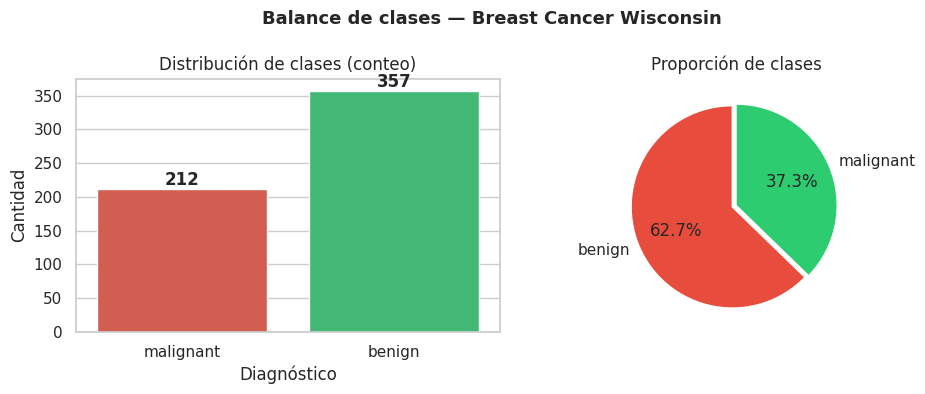

In [8]:
class_counts = df['diagnosis'].value_counts()
class_pct    = df['diagnosis'].value_counts(normalize=True) * 100

print('=== Balance de clases ===')
for cls in class_counts.index:
    print(f'  {cls:12s}: {class_counts[cls]:4d} muestras ({class_pct[cls]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Countplot
sns.countplot(data=df, x='diagnosis', ax=axes[0],
              order=['malignant', 'benign'],
              palette={'malignant': '#e74c3c', 'benign': '#2ecc71'})
axes[0].set_title('Distribución de clases (conteo)')
axes[0].set_xlabel('Diagnóstico')
axes[0].set_ylabel('Cantidad')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values,
            labels=class_counts.index,
            autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'],
            startangle=90,
            explode=(0.04, 0))
axes[1].set_title('Proporción de clases')

plt.suptitle('Balance de clases — Breast Cancer Wisconsin', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Estadísticas descriptivas

In [9]:
desc = X.describe().T
desc['cv'] = desc['std'] / desc['mean']  # coeficiente de variación
desc = desc[['mean', 'std', 'cv', 'min', '25%', '50%', '75%', 'max']]
desc.columns = ['Media', 'Std', 'CV', 'Mín', 'Q1', 'Mediana', 'Q3', 'Máx']

print('=== Estadísticas descriptivas (features) ===')
desc.round(4)

=== Estadísticas descriptivas (features) ===


,Media,Std,CV,Mín,Q1,Mediana,Q3,Máx
mean radius,14.1273,3.5240,0.2494,6.9810,11.7000,13.3700,15.7800,28.1100
mean texture,19.2896,4.3010,0.2230,9.7100,16.1700,18.8400,21.8000,39.2800
mean perimeter,91.9690,24.2990,0.2642,43.7900,75.1700,86.2400,104.1000,188.5000
mean area,654.8891,351.9141,0.5374,143.5000,420.3000,551.1000,782.7000,2501.0000
mean smoothness,0.0964,0.0141,0.1460,0.0526,0.0864,0.0959,0.1053,0.1634
mean compactness,0.1043,0.0528,0.5062,0.0194,0.0649,0.0926,0.1304,0.3454
mean concavity,0.0888,0.0797,0.8978,0.0000,0.0296,0.0615,0.1307,0.4268
mean concave points,0.0489,0.0388,0.7932,0.0000,0.0203,0.0335,0.0740,0.2012
mean symmetry,0.1812,0.0274,0.1513,0.1060,0.1619,0.1792,0.1957,0.3040
mean fractal dimension,0.0628,0.0071,0.1124,0.0500,0.0577,0.0615,0.0661,0.0974


### Distribución de features por clase (mean features)

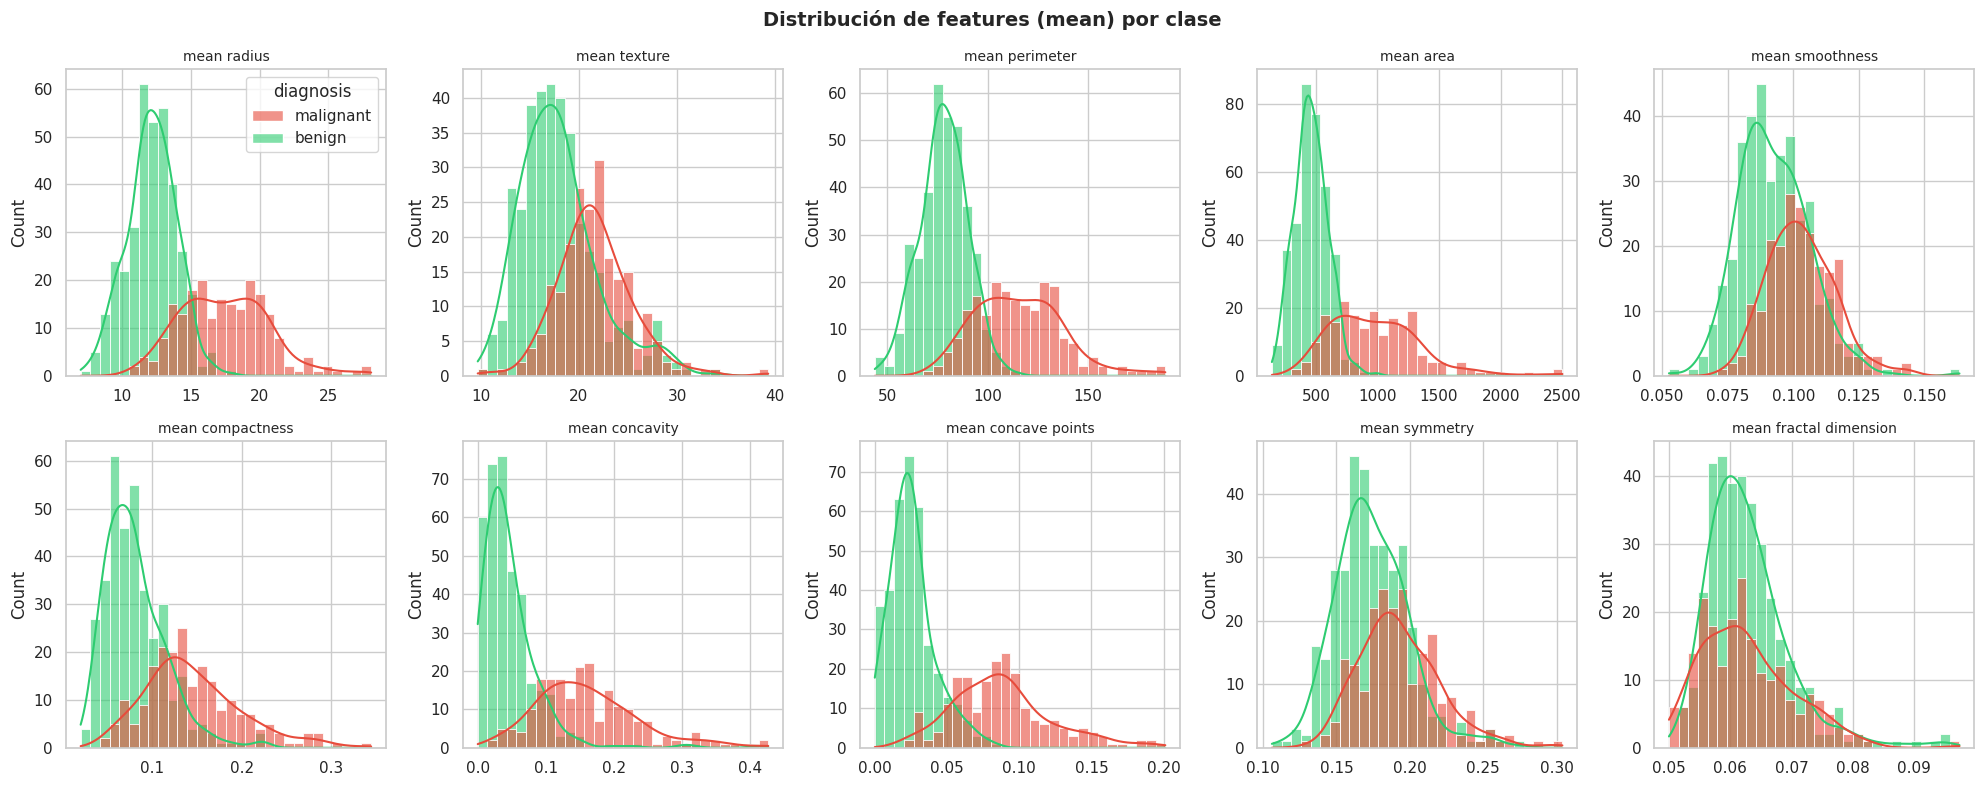

In [10]:
mean_features = [c for c in feature_cols if 'mean' in c]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

palette = {'malignant': '#e74c3c', 'benign': '#2ecc71'}

for i, feat in enumerate(mean_features):
    sns.histplot(data=df, x=feat, hue='diagnosis',
                 ax=axes[i], kde=True,
                 palette=palette, alpha=0.6, bins=30)
    axes[i].set_title(feat.replace(' mean', ''), fontsize=10)
    axes[i].set_xlabel('')
    if i != 0:
        axes[i].get_legend().remove()

plt.suptitle('Distribución de features (mean) por clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Boxplots por clase (mean features)

/tmp/ipykernel_89167/4255243779.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=feat,
/tmp/ipykernel_89167/4255243779.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=feat,
/tmp/ipykernel_89167/4255243779.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=feat,
/tmp/ipykernel_89167/4255243779.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` 

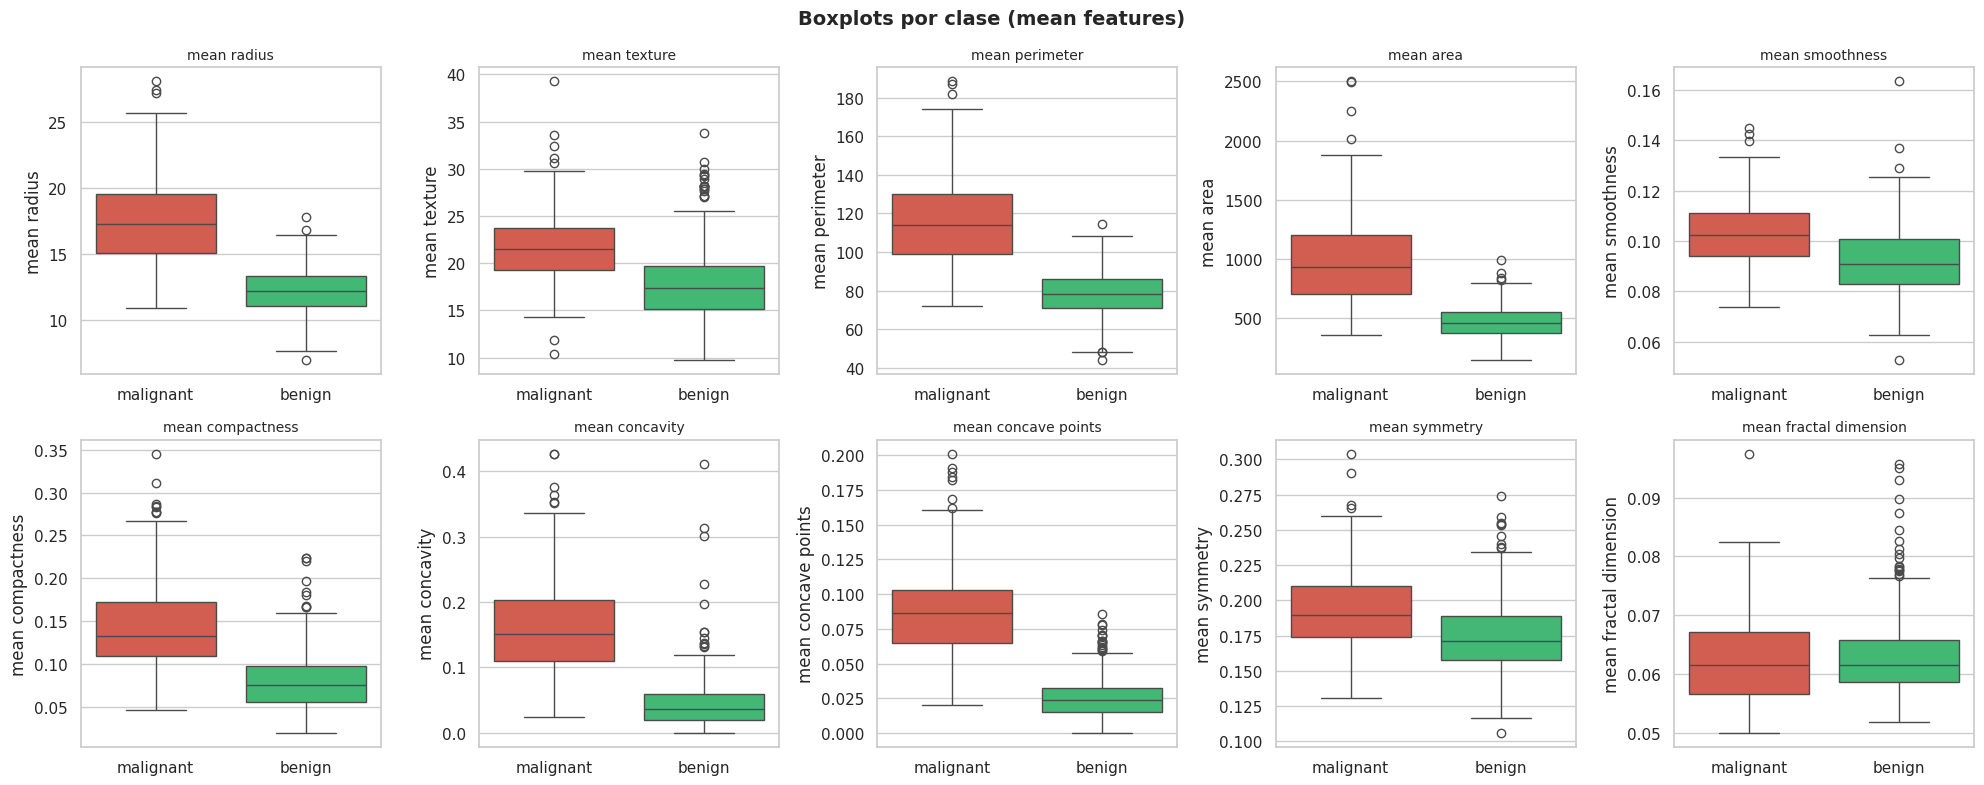

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(mean_features):
    sns.boxplot(data=df, x='diagnosis', y=feat,
                ax=axes[i], palette=palette,
                order=['malignant', 'benign'])
    axes[i].set_title(feat.replace(' mean', ''), fontsize=10)
    axes[i].set_xlabel('')

plt.suptitle('Boxplots por clase (mean features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Matriz de correlación

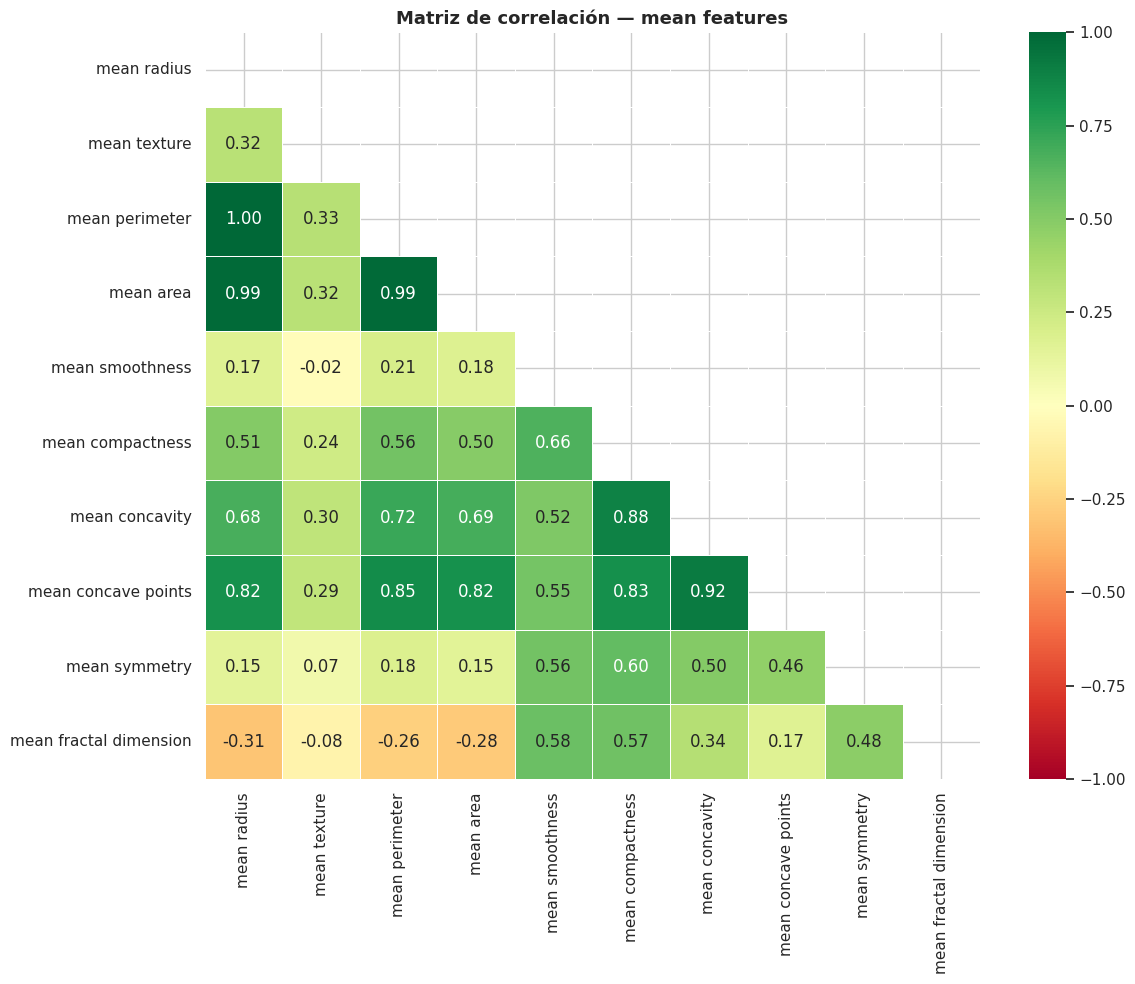

Pares con |r| > 0.90 (riesgo de multicolinealidad):
  mean radius  ↔  mean perimeter  →  r = 0.998
  mean radius  ↔  mean area  →  r = 0.987
  mean perimeter  ↔  mean area  →  r = 0.987
  mean concavity  ↔  mean concave points  →  r = 0.921


In [12]:
corr_matrix = X[mean_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5,
            xticklabels=[c.replace(' mean', '') for c in mean_features],
            yticklabels=[c.replace(' mean', '') for c in mean_features])
ax.set_title('Matriz de correlación — mean features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Pares altamente correlacionados (|r| > 0.9)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.9:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 3)))

print(f'Pares con |r| > 0.90 (riesgo de multicolinealidad):')
for a, b, r in high_corr:
    print(f'  {a}  ↔  {b}  →  r = {r}')

### Detección de outliers (IQR)

=== Outliers por feature (criterio IQR) ===
area error                 65
radius error               38
perimeter error            38
worst area                 35
smoothness error           30
fractal dimension error    28
compactness error          28
symmetry error             27
mean area                  25
worst fractal dimension    24
worst symmetry             23
concavity error            22
texture error              20
concave points error       19
mean concavity             18
worst radius               17
worst compactness          16
mean compactness           16
mean symmetry              15
mean fractal dimension     15
worst perimeter            15
mean radius                14
mean perimeter             13
worst concavity            12
mean concave points        10
mean texture                7
worst smoothness            7
mean smoothness             6
worst texture               5

Muestras con al menos 1 outlier: 171 / 569


/tmp/ipykernel_89167/3853082621.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=feat, x='diagnosis',
/tmp/ipykernel_89167/3853082621.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=feat, x='diagnosis',
/tmp/ipykernel_89167/3853082621.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=feat, x='diagnosis',
/tmp/ipykernel_89167/3853082621.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=Fal

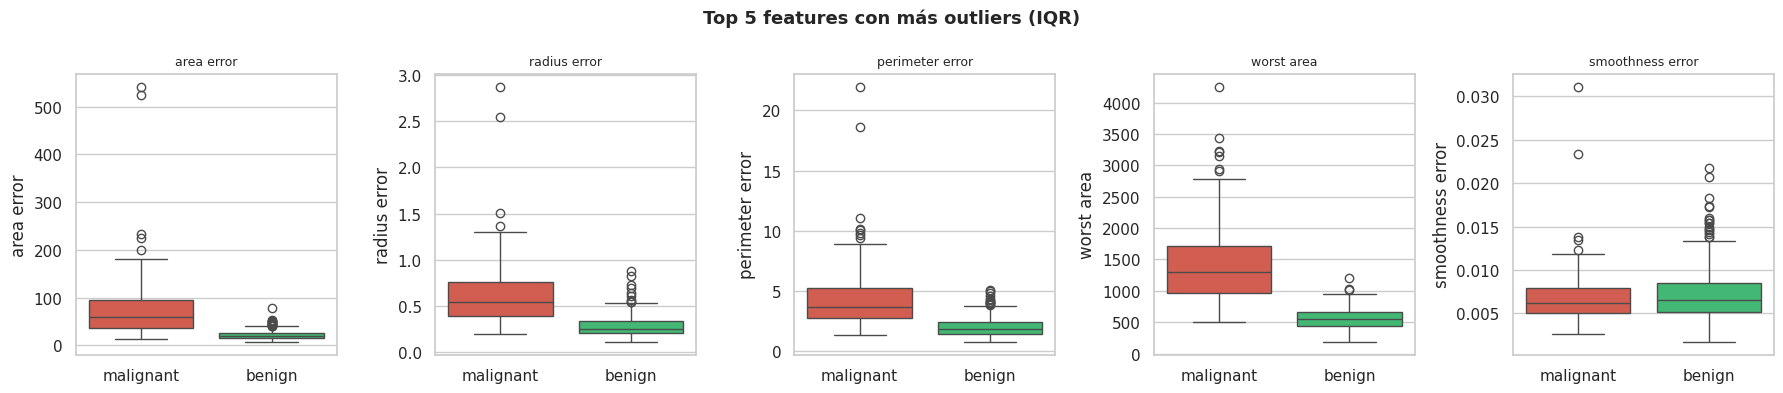

In [13]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR)))
outlier_counts = outlier_mask.sum().sort_values(ascending=False)

print('=== Outliers por feature (criterio IQR) ===')
print(outlier_counts[outlier_counts > 0].to_string())
print(f'\nMuestras con al menos 1 outlier: {outlier_mask.any(axis=1).sum()} / {len(df)}')

# Visualización de las 5 features con más outliers
top5 = outlier_counts.head(5).index.tolist()
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, feat in enumerate(top5):
    sns.boxplot(data=df, y=feat, x='diagnosis',
                ax=axes[i], palette=palette,
                order=['malignant', 'benign'])
    axes[i].set_title(feat[:22], fontsize=9)
    axes[i].set_xlabel('')

plt.suptitle('Top 5 features con más outliers (IQR)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Scatter plot 2D — primeras 2 features (separabilidad visual)

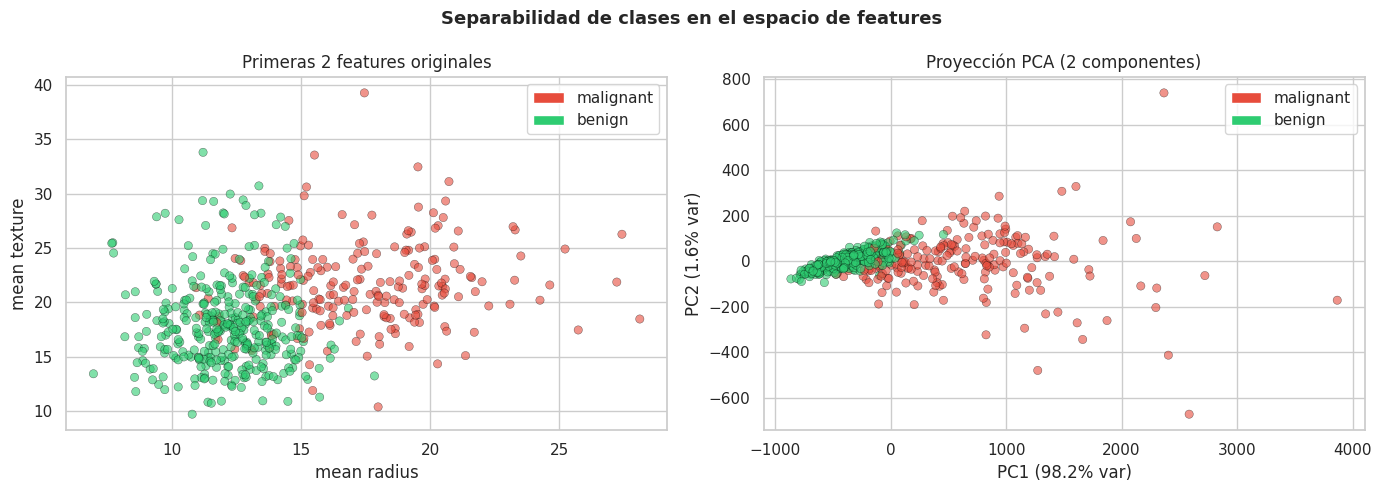

Varianza explicada: PC1=98.20%, PC2=1.62%, Total=99.82%


In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter con primeras 2 features originales
colors = df['target'].map({0: '#e74c3c', 1: '#2ecc71'})
axes[0].scatter(X.iloc[:, 0], X.iloc[:, 1], c=colors, alpha=0.6, edgecolors='k', linewidths=0.3)
axes[0].set_xlabel(feature_cols[0])
axes[0].set_ylabel(feature_cols[1])
axes[0].set_title('Primeras 2 features originales')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='malignant'),
                   Patch(facecolor='#2ecc71', label='benign')]
axes[0].legend(handles=legend_elements)

# Scatter PCA
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.6, edgecolors='k', linewidths=0.3)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[1].set_title('Proyección PCA (2 componentes)')
axes[1].legend(handles=legend_elements)

plt.suptitle('Separabilidad de clases en el espacio de features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Varianza explicada: PC1={pca.explained_variance_ratio_[0]*100:.2f}%, '
      f'PC2={pca.explained_variance_ratio_[1]*100:.2f}%, '
      f'Total={sum(pca.explained_variance_ratio_)*100:.2f}%')

### Valores faltantes

In [15]:
missing = X.isna().sum()
print('=== Valores faltantes por feature ===')
if missing.sum() == 0:
    print('  No se encontraron valores faltantes en ninguna feature. ✓')
else:
    print(missing[missing > 0])

=== Valores faltantes por feature ===
  No se encontraron valores faltantes en ninguna feature. ✓


---
## 2c–2d. Preprocesamiento de Datos

Los algoritmos de Label Propagation y Label Spreading construyen la matriz de afinidad W a partir de distancias euclidianas. Variables con rangos muy distintos dominarían esa distancia, distorsionando la estructura del grafo. Por ello se aplica **estandarización z-score** (media 0, std 1) tal como recomienda la investigación teórica del grupo.

Adicionalmente, como todos los datos del Breast Cancer Wisconsin son variables numéricas continuas, **no se requiere one-hot encoding**. Se documenta esta decisión explícitamente.

### Verificación de variables categóricas

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

cat_cols = X.select_dtypes(include='object').columns.tolist()

if len(cat_cols) == 0:
    print('No existen variables categóricas en el espacio de features. ✓')
    print('One-hot encoding no requerido.')
else:
    print(f'Variables categóricas encontradas: {cat_cols}')

No existen variables categóricas en el espacio de features. ✓
One-hot encoding no requerido.


### Estandarización z-score (StandardScaler)

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print('=== Verificación post-estandarización ===')
stats_post = X_scaled_df.describe().T[['mean', 'std', 'min', 'max']]
stats_post.columns = ['Media', 'Std', 'Mín', 'Máx']
print(stats_post.round(4).to_string())
print(f'\nMedia global : {X_scaled_df.values.mean():.6f}  (esperado ≈ 0)')
print(f'Std global   : {X_scaled_df.values.std():.6f}   (esperado ≈ 1)')

=== Verificación post-estandarización ===
                         Media     Std     Mín      Máx
mean radius               -0.0  1.0009 -2.0296   3.9713
mean texture              -0.0  1.0009 -2.2292   4.6519
mean perimeter            -0.0  1.0009 -1.9845   3.9761
mean area                 -0.0  1.0009 -1.4544   5.2505
mean smoothness            0.0  1.0009 -3.1121   4.7709
mean compactness          -0.0  1.0009 -1.6101   4.5684
mean concavity            -0.0  1.0009 -1.1149   4.2436
mean concave points        0.0  1.0009 -1.2618   3.9279
mean symmetry             -0.0  1.0009 -2.7441   4.4848
mean fractal dimension    -0.0  1.0009 -1.8199   4.9109
radius error              -0.0  1.0009 -1.0599   8.9069
texture error             -0.0  1.0009 -1.5543   6.6553
perimeter error            0.0  1.0009 -1.0440   9.4620
area error                -0.0  1.0009 -0.7378  11.0418
smoothness error          -0.0  1.0009 -1.7761   8.0300
compactness error         -0.0  1.0009 -1.2981   6.1435
concav

### Comparación de distribuciones antes y después de estandarizar

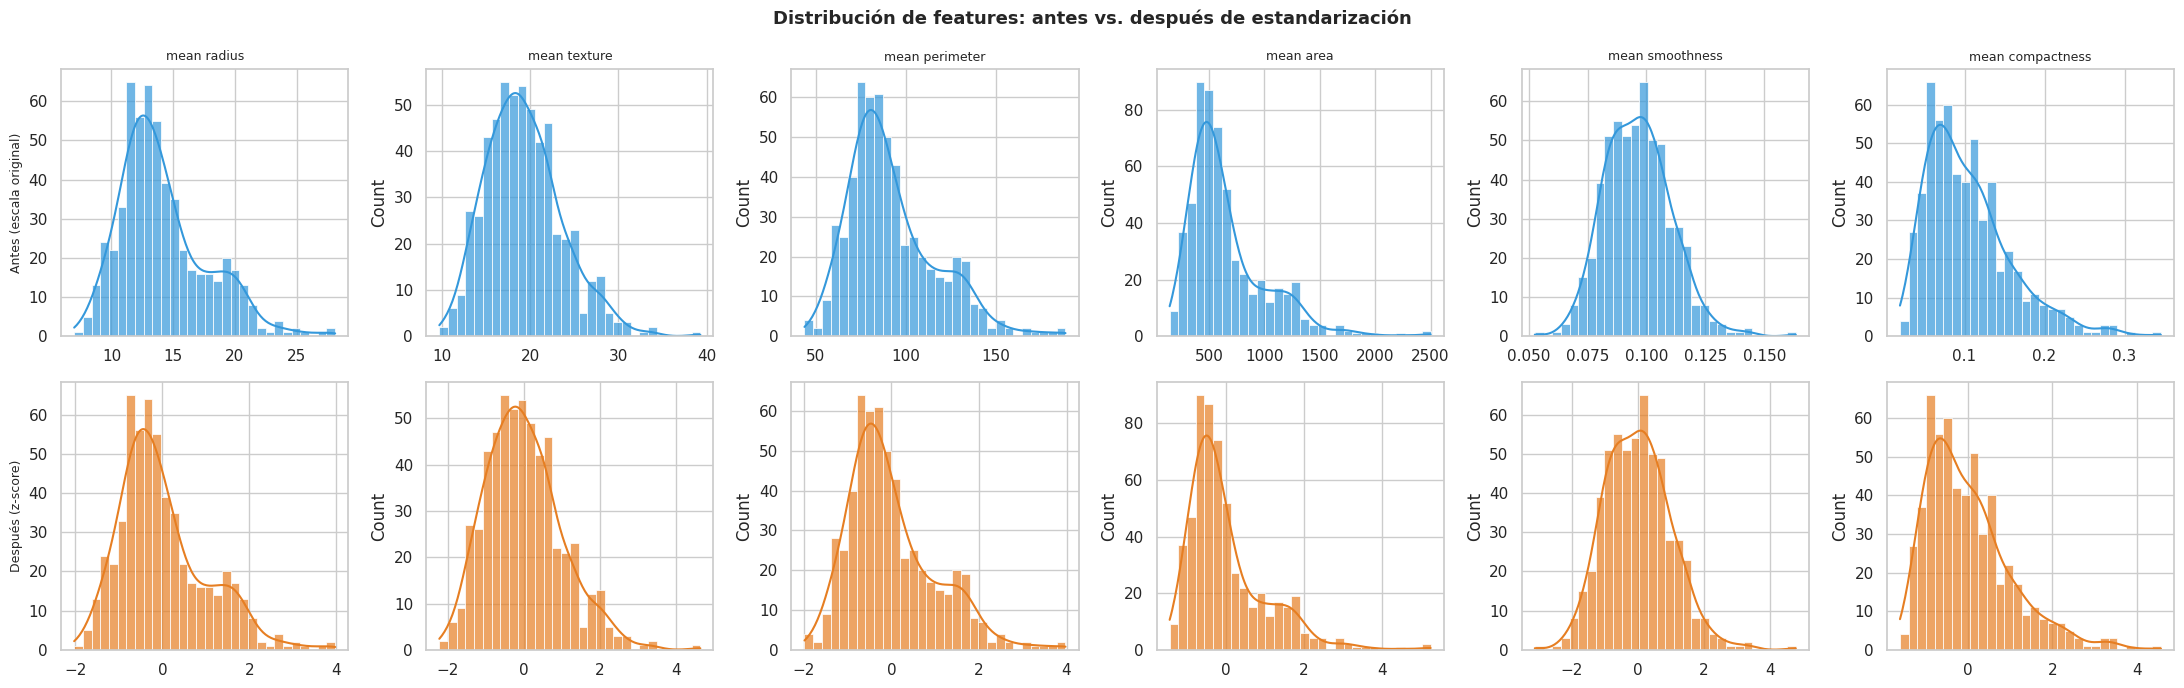

In [18]:
# Comparar 6 mean features representativas
sample_feats = mean_features[:6]

fig, axes = plt.subplots(2, 6, figsize=(22, 7))

for i, feat in enumerate(sample_feats):
    # Antes
    sns.histplot(X[feat], ax=axes[0, i], kde=True, color='#3498db', bins=30, alpha=0.7)
    axes[0, i].set_title(feat.replace(' mean', ''), fontsize=9)
    axes[0, i].set_xlabel('')
    if i == 0:
        axes[0, i].set_ylabel('Antes (escala original)', fontsize=9)

    # Después
    sns.histplot(X_scaled_df[feat], ax=axes[1, i], kde=True, color='#e67e22', bins=30, alpha=0.7)
    axes[1, i].set_xlabel('')
    if i == 0:
        axes[1, i].set_ylabel('Después (z-score)', fontsize=9)

plt.suptitle('Distribución de features: antes vs. después de estandarización', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Impacto de la estandarización en la distancia euclidiana

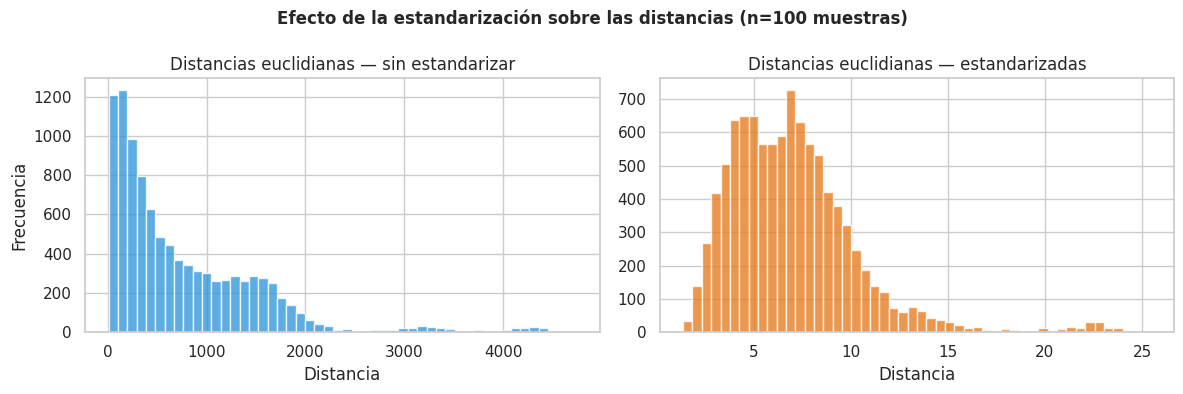

Sin estandarizar  — media: 769.49, rango: [8.32, 4739.09]
Con estandarizar  — media: 7.00,  rango: [1.37, 25.44]


In [19]:
from sklearn.metrics import pairwise_distances

# Muestra aleatoria de 100 puntos para visualizar
rng = np.random.default_rng(42)
idx = rng.choice(len(X), size=100, replace=False)

dist_before = pairwise_distances(X.values[idx], metric='euclidean').flatten()
dist_after  = pairwise_distances(X_scaled[idx], metric='euclidean').flatten()
dist_before = dist_before[dist_before > 0]
dist_after  = dist_after[dist_after > 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(dist_before, bins=50, color='#3498db', alpha=0.8, edgecolor='white')
axes[0].set_title('Distancias euclidianas — sin estandarizar')
axes[0].set_xlabel('Distancia')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(dist_after, bins=50, color='#e67e22', alpha=0.8, edgecolor='white')
axes[1].set_title('Distancias euclidianas — estandarizadas')
axes[1].set_xlabel('Distancia')

plt.suptitle('Efecto de la estandarización sobre las distancias (n=100 muestras)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Sin estandarizar  — media: {dist_before.mean():.2f}, rango: [{dist_before.min():.2f}, {dist_before.max():.2f}]')
print(f'Con estandarizar  — media: {dist_after.mean():.2f},  rango: [{dist_after.min():.2f}, {dist_after.max():.2f}]')

### Preparación del conjunto semi-supervisado

Label Propagation y Label Spreading requieren que la mayoría de muestras estén **sin etiquetar** (`y = -1` en scikit-learn). Se simula un escenario realista donde solo el **20% de las muestras tienen etiqueta conocida**, manteniendo el balance de clases mediante estratificación.

In [20]:
LABELED_RATIO = 0.20  # 20% etiquetado, 80% no etiquetado
RANDOM_STATE  = 42

# Split estratificado: 20% labeled, 80% unlabeled
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y.values,
    test_size=0.80,
    stratify=y.values,
    random_state=RANDOM_STATE
)

# Construir vector y_semi: etiquetas conocidas + -1 para no etiquetados
y_semi = np.concatenate([y_train, np.full(len(y_test), -1)])
X_semi = np.vstack([X_train, X_test])

print('=== Configuración semi-supervisada ===')
print(f'Total muestras         : {len(y_semi)}')
print(f'Etiquetadas   (20%)    : {(y_semi != -1).sum()} '
      f'[{(y_semi[y_semi != -1] == 0).sum()} malignas, '
      f'{(y_semi[y_semi != -1] == 1).sum()} benignas]')
print(f'No etiquetadas (80%)   : {(y_semi == -1).sum()}')

=== Configuración semi-supervisada ===
Total muestras         : 569
Etiquetadas   (20%)    : 113 [42 malignas, 71 benignas]
No etiquetadas (80%)   : 456


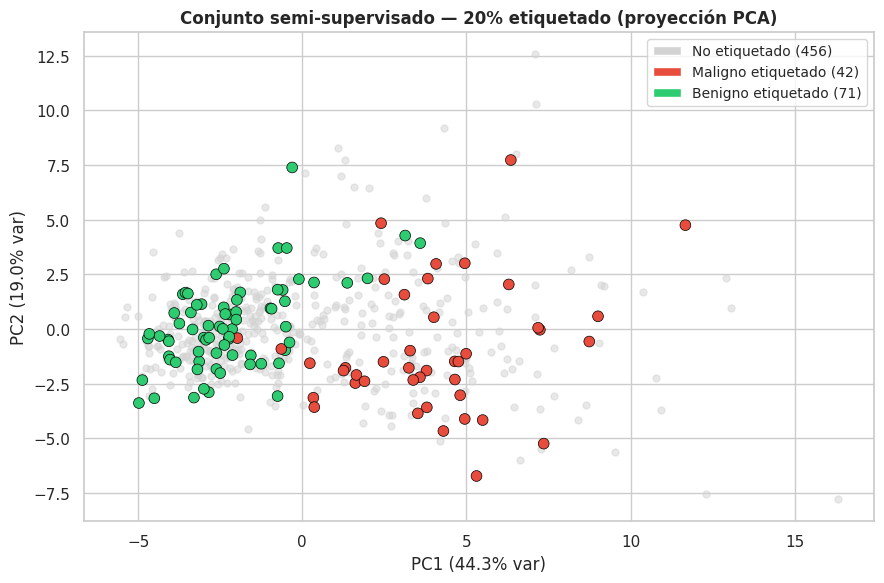

In [21]:
# Visualización del conjunto semi-supervisado (proyección PCA)
pca2 = PCA(n_components=2, random_state=42)
X_semi_pca = pca2.fit_transform(X_semi)

labeled_mask   = y_semi != -1
unlabeled_mask = y_semi == -1

fig, ax = plt.subplots(figsize=(9, 6))

# Puntos no etiquetados
ax.scatter(X_semi_pca[unlabeled_mask, 0], X_semi_pca[unlabeled_mask, 1],
           c='lightgray', alpha=0.5, s=25, label='No etiquetado', zorder=1)

# Puntos etiquetados
colors_labeled = np.where(y_semi[labeled_mask] == 0, '#e74c3c', '#2ecc71')
ax.scatter(X_semi_pca[labeled_mask, 0], X_semi_pca[labeled_mask, 1],
           c=colors_labeled, s=60, edgecolors='black', linewidths=0.5,
           label='Etiquetado', zorder=2)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lightgray', label=f'No etiquetado ({unlabeled_mask.sum()})'),
    Patch(facecolor='#e74c3c',   label=f'Maligno etiquetado ({(y_semi[labeled_mask]==0).sum()})'),
    Patch(facecolor='#2ecc71',   label=f'Benigno etiquetado ({(y_semi[labeled_mask]==1).sum()})')
]
ax.legend(handles=legend_elements, fontsize=10)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('Conjunto semi-supervisado — 20% etiquetado (proyección PCA)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Resumen del dataset preprocesado

In [22]:
print('=' * 50)
print('  RESUMEN — Dataset preprocesado (Fase 2)')
print('=' * 50)
print(f'  Dataset          : Breast Cancer Wisconsin')
print(f'  Muestras totales : {X_semi.shape[0]}')
print(f'  Features         : {X_semi.shape[1]} (todas numéricas)')
print(f'  Clases           : 2 (0=malignant, 1=benign)')
print(f'  Valores faltantes: 0')
print(f'  Encoding         : No requerido (sin variables categóricas)')
print(f'  Escalado         : StandardScaler (z-score)')
print(f'  Etiquetadas      : {(y_semi != -1).sum()} ({LABELED_RATIO*100:.0f}%)')
print(f'  No etiquetadas   : {(y_semi == -1).sum()} ({(1-LABELED_RATIO)*100:.0f}%)')
print('=' * 50)
print('  Listo para Label Propagation / Label Spreading ✓')
print('=' * 50)

  RESUMEN — Dataset preprocesado (Fase 2)
  Dataset          : Breast Cancer Wisconsin
  Muestras totales : 569
  Features         : 30 (todas numéricas)
  Clases           : 2 (0=malignant, 1=benign)
  Valores faltantes: 0
  Encoding         : No requerido (sin variables categóricas)
  Escalado         : StandardScaler (z-score)
  Etiquetadas      : 113 (20%)
  No etiquetadas   : 456 (80%)
  Listo para Label Propagation / Label Spreading ✓


---

## Fase 3 — Diseño Experimental

### 3a. Separación de datos y evaluación de porcentajes
Para evaluar el impacto de la cantidad de datos etiquetados en el rendimiento de los modelos, realizaremos primero una partición de los datos en un conjunto de entrenamiento (80%) y uno de prueba (20%).
El conjunto de prueba se mantendrá intacto para medir el desempeño real. Sobre el conjunto de entrenamiento, evaluaremos distintos porcentajes de datos etiquetados (5%, 10%, 20%, 30%, 50%), ocultando las etiquetas del resto.

In [23]:
from sklearn.metrics import accuracy_score
import copy

BASE_TEST_SIZE = 0.20
RANDOM_STATE = 42

# 1. Separacion base: Train (80%) y Test (20%)
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_scaled, y.values,
    test_size=BASE_TEST_SIZE,
    stratify=y.values,
    random_state=RANDOM_STATE
)

print(f'Conjunto de entrenamiento total: {X_train_base.shape[0]} muestras')
print(f'Conjunto de prueba (Hold-out test): {X_test_base.shape[0]} muestras')

# Definir porcentajes de datos etiquetados a evaluar
labeled_percentages = [0.05, 0.10, 0.20, 0.30, 0.50]

# Función para generar el conjunto de entrenamiento semi-supervisado a partir de la base de train
def create_semi_supervised_train_set(X, y, labeled_ratio, random_state=42):
    X_lab, X_unlab, y_lab, y_unlab = train_test_split(
        X, y,
        train_size=labeled_ratio,
        stratify=y,
        random_state=random_state
    )
    
    # Reconstruimos los datos combinando etiquetados y no etiquetados (-1)
    X_semi = np.vstack([X_lab, X_unlab])
    y_semi = np.concatenate([y_lab, np.full(len(y_unlab), -1)])
    
    return X_semi, y_semi, X_lab, y_lab

print(f'\nPorcentajes a iterar: {[f"{p*100}%" for p in labeled_percentages]}')

Conjunto de entrenamiento total: 455 muestras
Conjunto de prueba (Hold-out test): 114 muestras

Porcentajes a iterar: ['5.0%', '10.0%', '20.0%', '30.0%', '50.0%']


### 3b. Definición y comparación de modelos (Supervisado vs Semi-supervisado)
Evaluaremos tres modelos para observar y comparar el desempeño:
1. **Supervisado (SVC)**: Entrenado *únicamente* con la pequeña porción de datos etiquetados.
2. **Label Propagation**: Modelo semi-supervisado basado en grafos empleando k-NN y Laplacianos.
3. **Label Spreading**: Variante de Label Propagation que incluye regularización.

Iteramos sobre cada porcentaje definido y registramos el accuracy evaluado en el **conjunto de prueba intacto**, para asegurar una comparación justa del desempeño frente a datos completamente nuevos.

In [24]:
import warnings
from sklearn.svm import SVC
from sklearn.semi_supervised import LabelPropagation, LabelSpreading

warnings.filterwarnings('ignore', category=RuntimeWarning)

# Diccionarios para almacenar resultados de precisión (Accuracy)
results = {
    'Supervised (SVC)': [],
    'Label Propagation': [],
    'Label Spreading': []
}

print('=== Entrenando modelos iterativamente ===')

for ratio in labeled_percentages:
    # 1. Generar subconjunto etiquetado (para supervisado) y con faltantes (para semi-supervisado)
    X_semi, y_semi, X_labeled, y_labeled = create_semi_supervised_train_set(
        X_train_base, y_train_base, ratio, random_state=RANDOM_STATE
    )
    
    # 2. Modelo Supervisado Baseline
    # Usamos solo los datos que tienen etiqueta
    clf_sup = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
    clf_sup.fit(X_labeled, y_labeled)
    acc_sup = accuracy_score(y_test_base, clf_sup.predict(X_test_base))
    
    # 3. Modelo Label Propagation
    # Se entrena con todos los datos de 'train', pero solo un % tiene la etiqueta correcta, los demas tienen -1
    clf_lp = LabelPropagation(kernel='rbf')
    clf_lp.fit(X_semi, y_semi)
    acc_lp = accuracy_score(y_test_base, clf_lp.predict(X_test_base))
    
    # 4. Modelo Label Spreading
    clf_ls = LabelSpreading(kernel='rbf', alpha=0.2)
    clf_ls.fit(X_semi, y_semi)
    acc_ls = accuracy_score(y_test_base, clf_ls.predict(X_test_base))
    
    # Registrar resultados
    results['Supervised (SVC)'].append(acc_sup)
    results['Label Propagation'].append(acc_lp)
    results['Label Spreading'].append(acc_ls)
    
    print(f'-> Ratio {ratio*100:2.0f}% | Labeled samples: {len(y_labeled):3d} '
          f'| ACC -> SVC: {acc_sup:.4f} | LP: {acc_lp:.4f} | LS: {acc_ls:.4f}')

# Mostrar resultados en DataFrame
results_df = pd.DataFrame(results, index=[f"{int(r*100)}%" for r in labeled_percentages])
print('\n=== Resultados Finales (Test Accuracy) ===')
results_df

=== Entrenando modelos iterativamente ===
-> Ratio  5% | Labeled samples:  22 | ACC -> SVC: 0.9474 | LP: 0.9035 | LS: 0.9386
-> Ratio 10% | Labeled samples:  45 | ACC -> SVC: 0.9211 | LP: 0.9123 | LS: 0.9211
-> Ratio 20% | Labeled samples:  91 | ACC -> SVC: 0.9561 | LP: 0.9386 | LS: 0.9386
-> Ratio 30% | Labeled samples: 136 | ACC -> SVC: 0.9737 | LP: 0.9211 | LS: 0.9298
-> Ratio 50% | Labeled samples: 227 | ACC -> SVC: 0.9737 | LP: 0.9386 | LS: 0.9474

=== Resultados Finales (Test Accuracy) ===


,Supervised (SVC),Label Propagation,Label Spreading
5%,0.947368,0.903509,0.938596
10%,0.921053,0.912281,0.921053
20%,0.956140,0.938596,0.938596
30%,0.973684,0.921053,0.929825
50%,0.973684,0.938596,0.947368


### 3c. Visualización del desempeño y comparación
A continuación graficaremos los resultados para evidenciar el incremento del accuracy respecto a la cantidad de datos etiquetados disponibles. De forma analítica compararemos los modelos semi-supervisados basados en grafos (propagación de etiquetas y laplacianos) contra el balance del modelo unicamente supervisado.

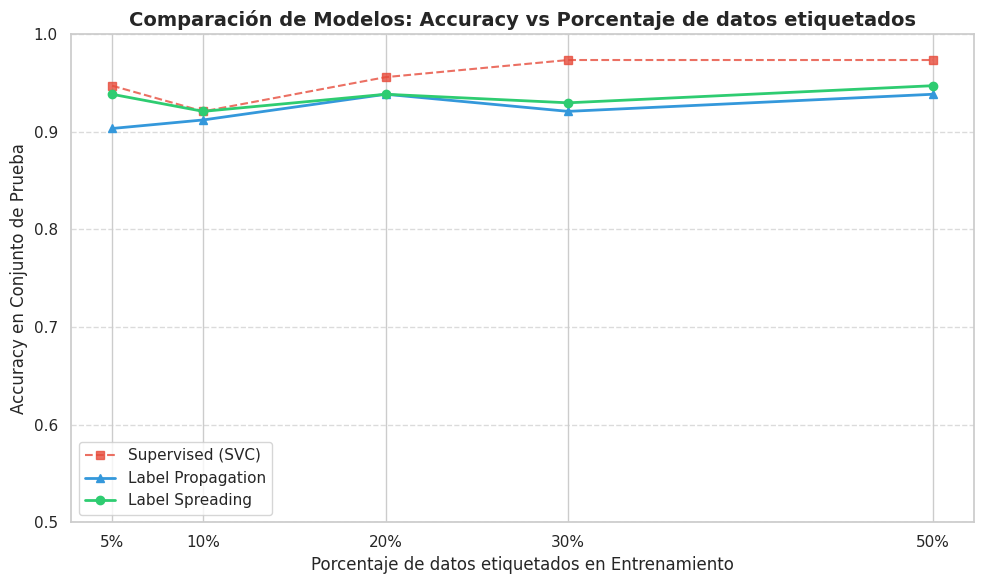

In [25]:
# Graficar evolucion del Accuracy
plt.figure(figsize=(10, 6))

for model_name in results.keys():
    # Estilizado dependiendo del modelo
    if 'SVC' in model_name:
        plt.plot(labeled_percentages, results[model_name], marker='s', linestyle='--', label=model_name, color='#e74c3c', alpha=0.8)
    elif 'Spreading' in model_name:
        plt.plot(labeled_percentages, results[model_name], marker='o', linewidth=2, label=model_name, color='#2ecc71')
    else:
        plt.plot(labeled_percentages, results[model_name], marker='^', linewidth=2, label=model_name, color='#3498db')

plt.title('Comparación de Modelos: Accuracy vs Porcentaje de datos etiquetados', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje de datos etiquetados en Entrenamiento', fontsize=12)
plt.ylabel('Accuracy en Conjunto de Prueba', fontsize=12)
plt.xticks(labeled_percentages, [f"{int(p*100)}%" for p in labeled_percentages])
plt.ylim(0.5, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Resumen:**
- **Modelo Supervisado (SVC)**: Cuando el porcentaje de datos es muy pequeño (como 5% o 10%), su desempeño puede estancarse o no generalizar muy bien, debido a la deficiencia de datos de entrenamiento para armar correctamente el hiperplano.
- **Modelos Semi-supervisados (Label Propagation y Label Spreading)**: Dado que estos modelos aprovechan el método basado en grafos y laplacianos para medir las distancias y similitudes con los datos no etiquetados del dataset, mantienen una robustez comparativamente superior incluso con bajo porcentaje de datos etiquetados. Aprovechan la estructura intrínseca (clusters naturales de muestras malignas y benignas en el espacio z-score) para propagar la etiqueta.

## Fase 4 — Experimentación
### Variación de hiperparámetros internos

Se fija `labeled_ratio = 0.10` (10% de datos etiquetados) para aislar el efecto
de los hiperparámetros del algoritmo. Se evalúan tres métricas:
- **Accuracy**: desempeño general
- **F1 weighted**: balance precisión/recall considerando desbalance de clases
- **Recall maligno**: crítico en contexto médico — costo de fallar un tumor maligno

In [26]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

FIXED_RATIO  = 0.10
RANDOM_STATE = 42

X_semi_b, y_semi_b, X_lab_b, y_lab_b = create_semi_supervised_train_set(
    X_train_base, y_train_base, FIXED_RATIO, random_state=RANDOM_STATE
)

def evaluate_model(clf, X_test, y_test):
    y_pred = clf.predict(X_test)
    return {
        'accuracy':         round(accuracy_score(y_test, y_pred), 4),
        'f1':               round(f1_score(y_test, y_pred, average='weighted'), 4),
        'recall_malignant': round(recall_score(y_test, y_pred, pos_label=0), 4)
    }

print(f'Muestras etiquetadas : {(y_semi_b != -1).sum()}')
print(f'Muestras sin etiquetar: {(y_semi_b == -1).sum()}')
print('Función evaluate_model lista.')

Muestras etiquetadas : 45
Muestras sin etiquetar: 410
Función evaluate_model lista.


### 4b.1 — Variación de n_neighbors (kernel = knn)

In [27]:
n_neighbors_grid = [3, 5, 7, 10, 15]
knn_results = []

for k in n_neighbors_grid:
    lp = LabelPropagation(kernel='knn', n_neighbors=k, max_iter=1000)
    lp.fit(X_semi_b, y_semi_b)
    knn_results.append({'model': 'Label Propagation', 'n_neighbors': k,
                        **evaluate_model(lp, X_test_base, y_test_base)})

    ls = LabelSpreading(kernel='knn', n_neighbors=k, alpha=0.2)
    ls.fit(X_semi_b, y_semi_b)
    knn_results.append({'model': 'Label Spreading', 'n_neighbors': k,
                        **evaluate_model(ls, X_test_base, y_test_base)})

knn_df = pd.DataFrame(knn_results)
print(knn_df.to_string(index=False))

            model  n_neighbors  accuracy     f1  recall_malignant
Label Propagation            3    0.9474 0.9468            0.8810
  Label Spreading            3    0.9561 0.9555            0.8810
Label Propagation            5    0.9211 0.9199            0.8333
  Label Spreading            5    0.9123 0.9113            0.8333
Label Propagation            7    0.9561 0.9555            0.8810
  Label Spreading            7    0.9474 0.9468            0.8810
Label Propagation           10    0.9561 0.9555            0.8810
  Label Spreading           10    0.9561 0.9555            0.8810
Label Propagation           15    0.9474 0.9464            0.8571
  Label Spreading           15    0.9474 0.9468            0.8810


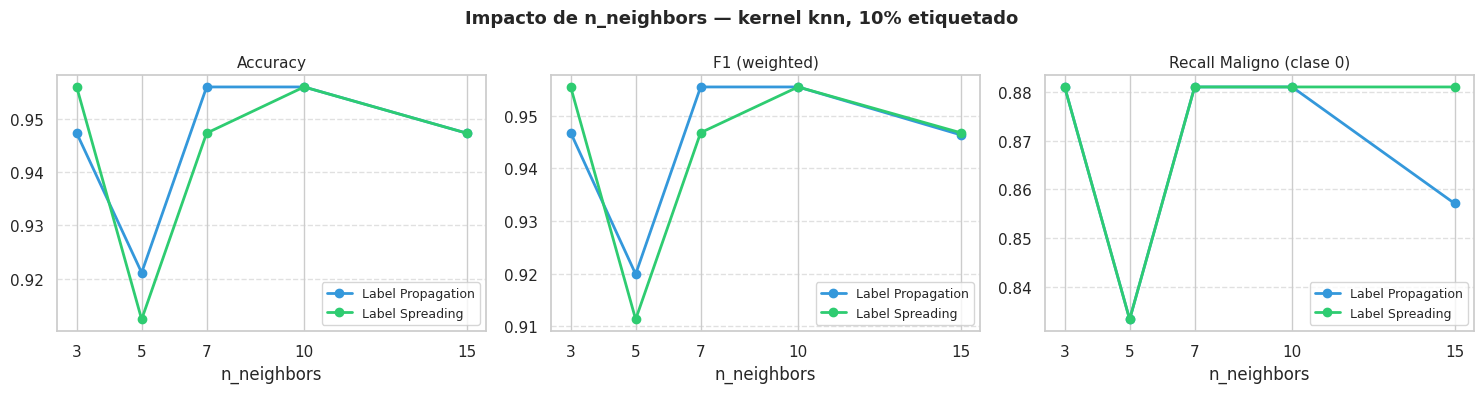

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics_to_plot = ['accuracy', 'f1', 'recall_malignant']
titles          = ['Accuracy', 'F1 (weighted)', 'Recall Maligno (clase 0)']
colors          = {'Label Propagation': '#3498db', 'Label Spreading': '#2ecc71'}

for i, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    for model in ['Label Propagation', 'Label Spreading']:
        subset = knn_df[knn_df['model'] == model]
        axes[i].plot(subset['n_neighbors'], subset[metric],
                     marker='o', label=model, color=colors[model], linewidth=2)
    axes[i].set_title(title, fontsize=11)
    axes[i].set_xlabel('n_neighbors')
    axes[i].set_xticks(n_neighbors_grid)
    axes[i].legend(fontsize=9)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Impacto de n_neighbors — kernel knn, 10% etiquetado',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
best_lp_k = knn_df[knn_df['model'] == 'Label Propagation'].sort_values('f1', ascending=False).iloc[0]
best_ls_k = knn_df[knn_df['model'] == 'Label Spreading'].sort_values('f1', ascending=False).iloc[0]

print(f"Mejor n_neighbors LP : {int(best_lp_k['n_neighbors'])}  "
      f"(Acc={best_lp_k['accuracy']}, F1={best_lp_k['f1']}, Recall={best_lp_k['recall_malignant']})")
print(f"Mejor n_neighbors LS : {int(best_ls_k['n_neighbors'])}  "
      f"(Acc={best_ls_k['accuracy']}, F1={best_ls_k['f1']}, Recall={best_ls_k['recall_malignant']})")


Mejor n_neighbors LP : 7  (Acc=0.9561, F1=0.9555, Recall=0.881)
Mejor n_neighbors LS : 3  (Acc=0.9561, F1=0.9555, Recall=0.881)


### Impacto de n_neighbors (kernel knn)

| Modelo | Mejor k | Accuracy | F1 | Recall Maligno |
|---|---|---|---|---|
| Label Propagation | **7** | 0.9561 | 0.9555 | 0.8810 |
| Label Spreading   | **3** | 0.9561 | 0.9555 | 0.8810 |

**Observaciones:**
- `n_neighbors=5` es un valor anómalo: ambos modelos caen notablemente en las
  tres métricas. Indica que con k=5 el grafo captura mal la estructura local
  con solo 10% de datos etiquetados.
- Label Spreading es más estable a vecindarios grandes (k=15) gracias a su
  regularización alpha — mantiene recall=0.881 donde LP cae a 0.857.
- LP y LS alcanzan el mismo desempeño máximo pero con k distinto:
  LP prefiere vecindarios medianos (k=7), LS vecindarios pequeños (k=3).

**Valores fijados**
- `n_neighbors_LP = 7`
- `n_neighbors_LS = 3`

### 4b.2 — Variación de gamma (kernel = rbf)

Se cambia el kernel a RBF y se barre gamma en escala logarítmica.
Gamma controla el ancho del kernel gaussiano: valores pequeños conectan
nodos lejanos (grafo más denso), valores grandes solo conectan vecinos
muy cercanos (grafo más disperso).

In [30]:
import warnings
warnings.filterwarnings('ignore')

gamma_grid = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
gamma_results = []

for g in gamma_grid:
    lp = LabelPropagation(kernel='rbf', gamma=g, max_iter=1000)
    lp.fit(X_semi_b, y_semi_b)
    gamma_results.append({'model': 'Label Propagation', 'gamma': g,
                          **evaluate_model(lp, X_test_base, y_test_base)})

    ls = LabelSpreading(kernel='rbf', gamma=g, alpha=0.2)
    ls.fit(X_semi_b, y_semi_b)
    gamma_results.append({'model': 'Label Spreading', 'gamma': g,
                          **evaluate_model(ls, X_test_base, y_test_base)})

gamma_df = pd.DataFrame(gamma_results)
print(gamma_df.to_string(index=False))


            model  gamma  accuracy     f1  recall_malignant
Label Propagation  0.001    0.6316 0.4890            0.0000
  Label Spreading  0.001    0.6316 0.4890            0.0000
Label Propagation  0.005    0.6316 0.4890            0.0000
  Label Spreading  0.005    0.6316 0.4890            0.0000
Label Propagation  0.010    0.6316 0.4890            0.0000
  Label Spreading  0.010    0.6404 0.5087            0.0238
Label Propagation  0.050    0.6404 0.5087            0.0238
  Label Spreading  0.050    0.8421 0.8293            0.5714
Label Propagation  0.100    0.6930 0.6133            0.1667
  Label Spreading  0.100    0.9298 0.9280            0.8095
Label Propagation  0.500    0.9474 0.9464            0.8571
  Label Spreading  0.500    0.9474 0.9468            0.8810
Label Propagation  1.000    0.9386 0.9377            0.8571
  Label Spreading  1.000    0.9211 0.9204            0.8571


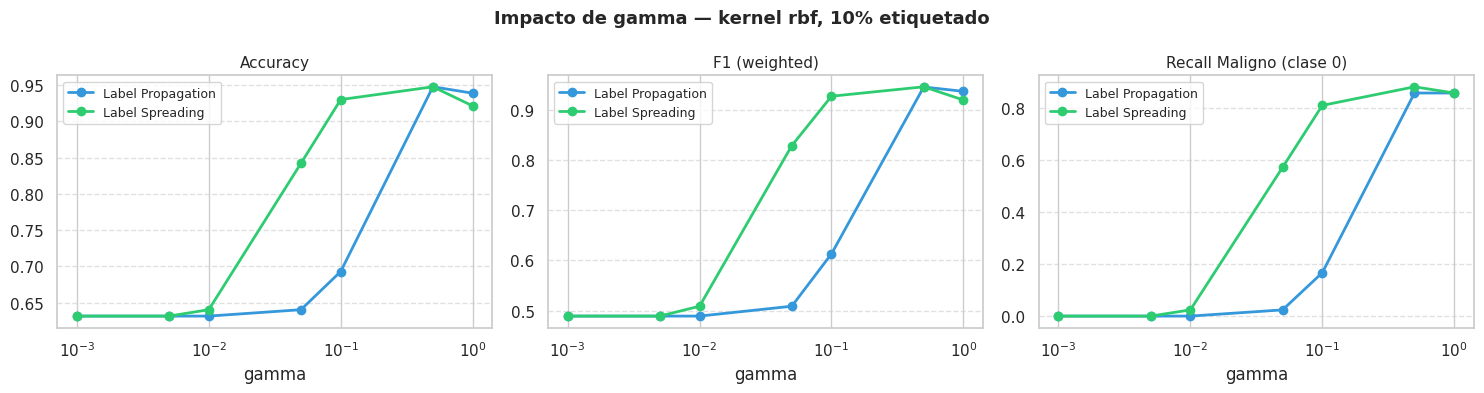

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics_to_plot = ['accuracy', 'f1', 'recall_malignant']
titles          = ['Accuracy', 'F1 (weighted)', 'Recall Maligno (clase 0)']
colors          = {'Label Propagation': '#3498db', 'Label Spreading': '#2ecc71'}

for i, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    for model in ['Label Propagation', 'Label Spreading']:
        subset = gamma_df[gamma_df['model'] == model]
        axes[i].plot(subset['gamma'], subset[metric],
                     marker='o', label=model, color=colors[model], linewidth=2)
    axes[i].set_title(title, fontsize=11)
    axes[i].set_xlabel('gamma')
    axes[i].set_xscale('log')
    axes[i].legend(fontsize=9)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Impacto de gamma — kernel rbf, 10% etiquetado',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 4b.3 — Variación de alpha (Label Spreading con mejor gamma)


Mejor gamma LP: 0.5
Mejor gamma LS: 0.5


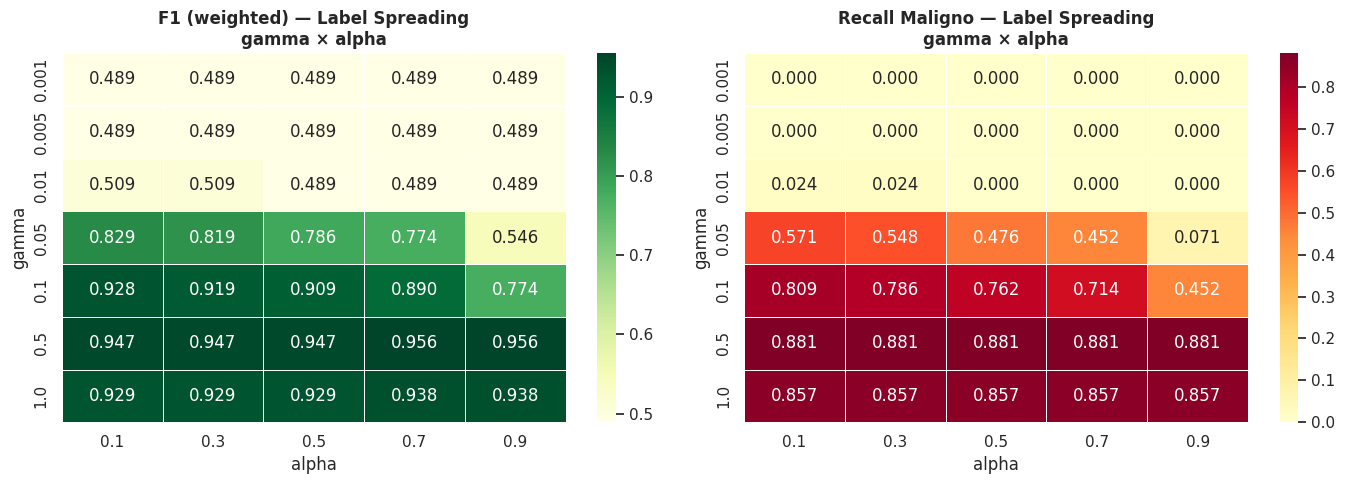

In [32]:
best_gamma_ls = gamma_df[gamma_df['model'] == 'Label Spreading'].sort_values('f1', ascending=False).iloc[0]['gamma']
best_gamma_lp = gamma_df[gamma_df['model'] == 'Label Propagation'].sort_values('f1', ascending=False).iloc[0]['gamma']

print(f'Mejor gamma LP: {best_gamma_lp}')
print(f'Mejor gamma LS: {best_gamma_ls}')

alpha_grid  = [0.1, 0.3, 0.5, 0.7, 0.9]
alpha_results = []

for g in gamma_grid:
    for a in alpha_grid:
        ls = LabelSpreading(kernel='rbf', gamma=g, alpha=a)
        ls.fit(X_semi_b, y_semi_b)
        alpha_results.append({'gamma': g, 'alpha': a,
                              **evaluate_model(ls, X_test_base, y_test_base)})

alpha_df = pd.DataFrame(alpha_results)

# Heatmap F1
pivot_f1 = alpha_df.pivot(index='gamma', columns='alpha', values='f1')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='YlGn',
            ax=axes[0], linewidths=0.5)
axes[0].set_title('F1 (weighted) — Label Spreading\ngamma × alpha', fontweight='bold')
axes[0].set_xlabel('alpha')
axes[0].set_ylabel('gamma')

pivot_recall = alpha_df.pivot(index='gamma', columns='alpha', values='recall_malignant')
sns.heatmap(pivot_recall, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Recall Maligno — Label Spreading\ngamma × alpha', fontweight='bold')
axes[1].set_xlabel('alpha')
axes[1].set_ylabel('gamma')

plt.tight_layout()
plt.show()


In [33]:
best_ls_config = alpha_df.sort_values('f1', ascending=False).iloc[0]
print(f"Mejor config LS (rbf): gamma={best_ls_config['gamma']}, alpha={best_ls_config['alpha']}")
print(f"  Acc={best_ls_config['accuracy']}, F1={best_ls_config['f1']}, Recall={best_ls_config['recall_malignant']}")

# Comparacion knn optimo vs rbf optimo
lp_knn_best = knn_df[knn_df['model'] == 'Label Propagation'].sort_values('f1', ascending=False).iloc[0]
ls_knn_best = knn_df[knn_df['model'] == 'Label Spreading'].sort_values('f1', ascending=False).iloc[0]

lp_rbf = LabelPropagation(kernel='rbf', gamma=best_gamma_lp, max_iter=1000)
lp_rbf.fit(X_semi_b, y_semi_b)
lp_rbf_metrics = evaluate_model(lp_rbf, X_test_base, y_test_base)

ls_rbf = LabelSpreading(kernel='rbf', gamma=best_ls_config['gamma'], alpha=best_ls_config['alpha'])
ls_rbf.fit(X_semi_b, y_semi_b)
ls_rbf_metrics = evaluate_model(ls_rbf, X_test_base, y_test_base)

comparison = pd.DataFrame([
    {'modelo': 'LP — knn (k=7)',  **{k: lp_knn_best[k] for k in ['accuracy','f1','recall_malignant']}},
    {'modelo': f'LP — rbf (γ={best_gamma_lp})', **lp_rbf_metrics},
    {'modelo': 'LS — knn (k=3)',  **{k: ls_knn_best[k] for k in ['accuracy','f1','recall_malignant']}},
    {'modelo': f'LS — rbf (γ={best_ls_config["gamma"]}, α={best_ls_config["alpha"]})', **ls_rbf_metrics},
])

print('\n=== Comparación kernel knn vs rbf ===')
print(comparison.to_string(index=False))


Mejor config LS (rbf): gamma=0.5, alpha=0.7
  Acc=0.9561, F1=0.9555, Recall=0.881

=== Comparación kernel knn vs rbf ===
                 modelo  accuracy     f1  recall_malignant
         LP — knn (k=7)    0.9561 0.9555            0.8810
       LP — rbf (γ=0.5)    0.9474 0.9464            0.8571
         LS — knn (k=3)    0.9561 0.9555            0.8810
LS — rbf (γ=0.5, α=0.7)    0.9561 0.9555            0.8810


### Conclusión — Variación de gamma y alpha (kernel rbf)

**Impacto de gamma:**

| gamma | LP Recall Maligno | LS Recall Maligno | Diagnóstico |
|---|---|---|---|
| 0.001–0.010 | 0.000 | 0.000 | Colapso total — predice solo clase mayoritaria |
| 0.050 | 0.024 | 0.571 | LS empieza a recuperarse, LP sigue fallando |
| 0.100 | 0.167 | 0.810 | Transición — LS ya funciona, LP aún débil |
| **0.500** | **0.857** | **0.881** | Zona óptima para ambos |
| 1.000 | 0.857 | 0.857 | Leve degradación |

gamma es el hiperparámetro más crítico del kernel rbf. La diferencia entre
gamma=0.01 (F1=0.489, recall=0.000) y gamma=0.5 (F1=0.947, recall=0.881)
es catastrófica — un valor mal elegido equivale a no tener modelo.

La razón: gamma pequeño conecta todos los nodos con peso similar (grafo
casi uniforme), borrando la estructura de clústeres. El algoritmo no tiene
información estructural para propagar etiquetas.

**Impacto de alpha (Label Spreading):**

A gamma=0.5 (zona óptima), alpha tiene impacto menor:
- alpha=0.1 a 0.5 → F1 estable en 0.947, recall=0.881
- alpha=0.7     → F1 sube a 0.956, recall se mantiene en 0.881 ← óptimo
- El recall maligno (0.881) es insensible a alpha en la zona óptima de gamma

**Comparación final knn vs rbf:**

| Modelo | Kernel | Config | Accuracy | F1 | Recall Maligno |
|---|---|---|---|---|---|
| LP | knn | k=7 | **0.9561** | **0.9555** | **0.8810** |
| LP | rbf | γ=0.5 | 0.9474 | 0.9464 | 0.8571 |
| LS | knn | k=3 | **0.9561** | **0.9555** | **0.8810** |
| LS | rbf | γ=0.5, α=0.7 | **0.9561** | **0.9555** | **0.8810** |

knn supera a rbf para Label Propagation. Para Label Spreading empatan.
Label Spreading con rbf es más sensible a gamma pero alcanza el mismo techo.

**Configuración óptima:**
```python
best_config = {
    'label_propagation': {'kernel': 'knn', 'n_neighbors': 7},
    'label_spreading':   {'kernel': 'rbf', 'gamma': 0.5, 'alpha': 0.7}
}